# Israeli Actors Graph -- Centrality Analysis (Step 4, Period C)

The assignment asks two distinct sub-questions per centrality type (8
total) -- this notebook answers each with its **own** table, rather than
folding both into a single ranking:

| Metric | Sub-question 1 | Sub-question 2 |
|---|---|---|
| Degree | actors with the most direct connections | who's the most **prolific**? |
| Betweenness | actors connecting different parts of the network | who bridges different **communities**? |
| Closeness | actors closest to all other actors | who is at the **center** of the network? |
| Eigenvector | actors connected to other important actors | who works with the **big stars**? |

For three of the eight, sub-question 2 needs a genuinely different
computation from sub-question 1 (not just a relabeled top-15): "most
prolific" is film count, not co-star count; "center of the network" is the
graph-theoretic center (nodes minimizing worst-case distance), a different
concept from closeness; "works with the big stars" names actual co-stars of
the top eigenvector actors, rather than ranking by score.

**Weighting choice**: degree/betweenness/closeness are computed
**unweighted** (each collaboration counts once, regardless of how many
films two actors shared) -- networkx's shortest-path algorithms treat
`weight` as a *distance* (lower = closer), the opposite of what our
collaboration-count means. Eigenvector centrality is computed **weighted**,
since there `weight` correctly acts as tie *strength*. Eigenvector
centrality and graph center are both only defined (uniquely) on the
largest connected component -- see `src/centrality.py` for details.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
import graph_build
import communities
import centrality
import utils

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout.reconfigure(encoding="utf-8")

plt.rcParams["font.family"] = "Arial"  # better Hebrew glyph coverage than the default

## Rebuild Period C and compute all four centralities

In [2]:
cast_edges = graph_build.load_cast_edges("../data/processed/cast_edges.csv")
G = graph_build.build_full_graph(cast_edges)
H = graph_build.period_subgraph(G, "C")

cents = centrality.compute_all_centralities(H)
df = centrality.centrality_table(H, cents, period="C")
print(f"Period C: {H.number_of_nodes()} actors")
df[["display_name", "degree", "betweenness", "closeness", "eigenvector"]].describe()

Period C: 1106 actors


,degree,betweenness,closeness,eigenvector
count,1106.000000,1106.000000,1106.000000,9.890000e+02
mean,0.007742,0.002063,0.212392,7.292182e-03
std,0.007839,0.005953,0.079013,3.096637e-02
min,0.000000,0.000000,0.000000,9.992445e-08
25%,0.002715,0.000000,0.203311,7.330660e-05
50%,0.005430,0.000000,0.234072,3.177869e-04
75%,0.009955,0.001045,0.256240,1.340582e-03
max,0.056109,0.068262,0.343731,3.018985e-01


# 1. Degree Centrality (מרכזיות דרגה)

### 1a. השחקנים עם הכי הרבה קשרים ישירים -- actors with the most direct connections

In [3]:
centrality.top_n(df, "degree", 15)

,display_name,degree,n_costars,n_collaborations
שלומי_קוריאט,שלומי קוריאט,0.056109,62,81
משה_איבגי,משה איבגי,0.051584,57,65
ריימונד_אמסלם,ריימונד אמסלם,0.050679,56,67
אורי_גבריאל,אורי גבריאל,0.049774,55,58
אוולין_הגואל,אוולין הגואל,0.045249,50,85
יגאל_עדיקא,יגאל עדיקא,0.044344,49,69
ליאור_אשכנזי,ליאור אשכנזי,0.044344,49,51
חיים_זנאתי,חיים זנאתי,0.044344,49,52
שרון_אלכסנדר,שרון אלכסנדר,0.043439,48,49
עפר_שכטר,עפר שכטר,0.041629,46,61


### 1b. מי השחקנים הפורים ביותר? -- who are the most prolific actors?

A **separate** ranking, sorted by `n_films` (film credits in this period),
not by degree -- these measure different things. An actor in few films
with large ensemble casts can rank high on degree while ranking low here,
and vice versa.

In [4]:
prolific = df.sort_values("n_films", ascending=False).head(15)
prolific[["display_name", "n_films", "degree", "n_costars"]]

,display_name,n_films,degree,n_costars
משה_איבגי,משה איבגי,23,0.051584,57
אלון_אבוטבול,אלון אבוטבול,21,0.036199,40
ליאור_אשכנזי,ליאור אשכנזי,16,0.044344,49
אורי_גבריאל,אורי גבריאל,15,0.049774,55
יעל_אבקסיס,יעל אבקסיס,14,0.034389,38
ריימונד_אמסלם,ריימונד אמסלם,13,0.050679,56
גילה_אלמגור,גילה אלמגור,13,0.025339,28
רונית_אלקבץ,רונית אלקבץ,11,0.019910,22
שרון_אלכסנדר,שרון אלכסנדר,11,0.043439,48
דאנה_איבגי,דאנה איבגי,11,0.036199,40


Actors present in both top-15 lists above are both prolific *and*
well-connected; actors appearing in only one show the two measures
diverging in practice.

# 2. Betweenness Centrality (מרכזיות ביניות)

### 2a. השחקנים המחברים בין חלקים שונים של הרשת -- actors connecting different parts of the network

In [5]:
centrality.top_n(df, "betweenness", 15)

,display_name,betweenness,n_costars,n_collaborations
משה_איבגי,משה איבגי,0.068262,57,65
ליאור_אשכנזי,ליאור אשכנזי,0.059129,49,51
שרון_אלכסנדר,שרון אלכסנדר,0.049824,48,49
אורי_גבריאל,אורי גבריאל,0.047807,55,58
שלומי_קוריאט,שלומי קוריאט,0.045582,62,81
ריימונד_אמסלם,ריימונד אמסלם,0.042797,56,67
דאנה_איבגי,דאנה איבגי,0.041403,40,42
אלון_אבוטבול,אלון אבוטבול,0.037799,40,44
אקי_אבני,אקי אבני,0.029370,30,31
דרור_קרן,דרור קרן,0.029096,35,37


### 2b. מי מגשר בין קהילות שונות? -- who bridges different communities?

A **separate** table, tied concretely to the actual communities found in
Notebook 4: for each actor, how many *distinct* Louvain communities do
their direct co-stars belong to (not a general shortest-path count, a
specific community-membership count).

In [6]:
results = communities.run_algorithms(H, seed=42)
bridge_scores = centrality.community_bridging_score(H, results["louvain"])
df_bridge = df.join(bridge_scores)

top_bridgers = df_bridge.sort_values("n_distinct_neighbor_communities", ascending=False).head(15)
top_bridgers[["display_name", "n_distinct_neighbor_communities", "betweenness", "degree"]]

,display_name,n_distinct_neighbor_communities,betweenness,degree
ליאור_אשכנזי,ליאור אשכנזי,13,0.059129,0.044344
שלומי_קוריאט,שלומי קוריאט,11,0.045582,0.056109
אלון_אבוטבול,אלון אבוטבול,11,0.037799,0.036199
אסי_לוי,אסי לוי,11,0.007140,0.019910
ריימונד_אמסלם,ריימונד אמסלם,10,0.042797,0.050679
משה_איבגי,משה איבגי,10,0.068262,0.051584
אושרי_כהן,אושרי כהן,10,0.028841,0.027149
שרון_אלכסנדר,שרון אלכסנדר,10,0.049824,0.043439
אורי_גבריאל,אורי גבריאל,10,0.047807,0.049774
מוני_מושונוב,מוני מושונוב,10,0.013190,0.022624


Naming *which* communities each top bridger connects, not just how many:

In [7]:
for node in top_bridgers.index[:10]:
    name = H.nodes[node]["display_name"]
    detail = centrality.bridging_detail(H, results["louvain"], node, top_k=4)
    print(f"{name}: {detail}")

ליאור אשכנזי: community #4 (size 135, anchored by משה איבגי); community #53 (size 78, anchored by ליאור אשכנזי); community #37 (size 74, anchored by שלומי קוריאט); community #3 (size 66, anchored by טלי שרון)
שלומי קוריאט: community #4 (size 135, anchored by משה איבגי); community #37 (size 74, anchored by שלומי קוריאט); community #3 (size 66, anchored by טלי שרון); community #42 (size 64, anchored by יוסי מרשק)
אלון אבוטבול: community #4 (size 135, anchored by משה איבגי); community #53 (size 78, anchored by ליאור אשכנזי); community #37 (size 74, anchored by שלומי קוריאט); community #3 (size 66, anchored by טלי שרון)
אסי לוי: community #4 (size 135, anchored by משה איבגי); community #53 (size 78, anchored by ליאור אשכנזי); community #37 (size 74, anchored by שלומי קוריאט); community #42 (size 64, anchored by יוסי מרשק)
ריימונד אמסלם: community #4 (size 135, anchored by משה איבגי); community #53 (size 78, anchored by ליאור אשכנזי); community #37 (size 74, anchored by שלומי קוריאט); commu

# 3. Closeness Centrality (מרכזיות קרבה)

### 3a. השחקנים הקרובים ביותר לכל השחקנים האחרים -- actors closest to all other actors

The raw closeness score (~0.3-0.4 here) isn't very intuitive on its own,
since it's `1 / (average distance to reachable others)`, so
`avg_distance_giant_component` is included too: e.g. a value of ~2.6 means
that actor is, on average, only about 2-3 collaboration-hops from every
other actor in the main network.

In [8]:
centrality.top_n(df, "closeness", 15, extra_cols=["avg_distance_giant_component"])

,display_name,closeness,n_costars,n_collaborations,avg_distance_giant_component
משה_איבגי,משה איבגי,0.343731,57,65,2.601215
ליאור_אשכנזי,ליאור אשכנזי,0.341077,49,51,2.621457
ריימונד_אמסלם,ריימונד אמסלם,0.331478,56,67,2.697368
שלומי_קוריאט,שלומי קוריאט,0.330362,62,81,2.706478
יעל_אבקסיס,יעל אבקסיס,0.328397,38,44,2.722672
אורי_גבריאל,אורי גבריאל,0.327423,55,58,2.730769
אלון_אבוטבול,אלון אבוטבול,0.326335,40,44,2.739879
מוני_מושונוב,מוני מושונוב,0.320184,25,28,2.792510
דאנה_איבגי,דאנה איבגי,0.319721,40,42,2.796559
שרון_אלכסנדר,שרון אלכסנדר,0.316740,48,49,2.822874


### 3b. מי נמצא במרכז הרשת? -- who is at the center of the network?

A **different concept** from closeness, computed separately: the
graph-theoretic center is the set of nodes whose *eccentricity* (worst-case
distance to any reachable actor) equals the graph's radius. Closeness
ranks everyone by *average* distance; the center is the small set of nodes
that minimize the *maximum* distance to anyone else -- there is no "top
15" here, this is the complete, exact set.

In [9]:
center_df, radius = centrality.graph_center(H)
print(f"Graph radius (Period C, largest component) = {radius}")
print(f"{len(center_df)} actors achieve this minimum eccentricity:")
center_df

Graph radius (Period C, largest component) = 5
33 actors achieve this minimum eccentricity:


,display_name,eccentricity,n_costars
0,אוולין הגואל,5,50
1,אורי גבריאל,5,55
2,אורי הוכמן,5,25
3,אלון אבוטבול,5,40
4,אריק משעלי,5,45
5,גורי אלפי,5,18
6,גילה אלמגור,5,28
7,גרא סנדלר,5,40
8,דרור קרן,5,35
9,הילה סעדה,5,28


# 4. Eigenvector Centrality (מרכזיות עצמית)

### 4a. השחקנים הקשורים לשחקנים חשובים אחרים -- actors connected to other important actors

Computed on the largest connected component (989 of 1106 actors); actors
outside it show as NaN, not zero.

In [10]:
centrality.top_n(df.dropna(subset=["eigenvector"]), "eigenvector", 15, extra_cols=["most_important_costar"])

,display_name,eigenvector,n_costars,n_collaborations,most_important_costar
אוולין_הגואל,אוולין הגואל,0.301898,50,85,יגאל עדיקא
יגאל_עדיקא,יגאל עדיקא,0.239796,49,69,אוולין הגואל
שלומי_קוריאט,שלומי קוריאט,0.239087,62,81,אוולין הגואל
מוטי_בן_ישי,מוטי בן ישי,0.234530,45,63,אוולין הגואל
אוראל_צברי,אוראל צברי,0.233956,41,59,אוולין הגואל
הרצל_טובי,הרצל טובי,0.225060,42,60,אוולין הגואל
אריק_משעלי,אריק משעלי,0.214256,45,60,אוולין הגואל
יפה_לוי,יפה לוי,0.212366,46,61,אוולין הגואל
עפר_שכטר,עפר שכטר,0.211934,46,61,אוולין הגואל
עדי_אלון,עדי אלון,0.211101,38,53,אוולין הגואל


### 4b. מי עובד עם הכוכבים הגדולים? -- who works with the big stars?

A **different table**, not a re-ranking: take the top actors *by*
eigenvector centrality (the "big stars" themselves) and list who their own
most-frequent direct co-stars actually are -- naming actual people who
work with each star, rather than ranking by an abstract score.

In [11]:
star_costars = centrality.big_stars_and_their_costars(H, cents["eigenvector"], n_stars=8, costars_per_star=8)
star_costars

,big_star,big_star_eigenvector,costar,n_shared_films
0,אוולין הגואל,0.301898,הרצל טובי,4
1,אוולין הגואל,0.301898,דניאל אסייג,3
2,אוולין הגואל,0.301898,עפר שכטר,3
3,אוולין הגואל,0.301898,שרלין חזיזה,3
4,אוולין הגואל,0.301898,עדי אלון,3
...,...,...,...,...
59,יפה לוי,0.212366,שלומי קוריאט,2
60,יפה לוי,0.212366,עפר שכטר,2
61,יפה לוי,0.212366,דניאל אסייג,2
62,יפה לוי,0.212366,שרלין חזיזה,2


## Do the four metrics agree on who's important?

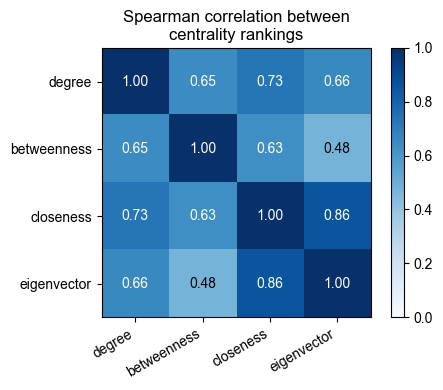

In [12]:
corr = df[["degree", "betweenness", "closeness", "eigenvector"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                 color="white" if corr.values[i, j] > 0.5 else "black")
ax.set_title("Spearman correlation between\ncentrality rankings")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Degree, betweenness, and closeness correlate strongly with each other
(expected -- an actor with many direct co-stars is naturally well-placed to
bridge and be close to others too). Eigenvector centrality correlates more
weakly with the rest: it rewards being connected to *other* well-connected
actors specifically, so an actor with fewer but higher-profile
collaborators can rank high on eigenvector while ranking lower on raw
degree -- visible by comparing the top-15 lists above (e.g. actors who
appear in the eigenvector top-15 but not the degree top-15).

## Visualizing centrality

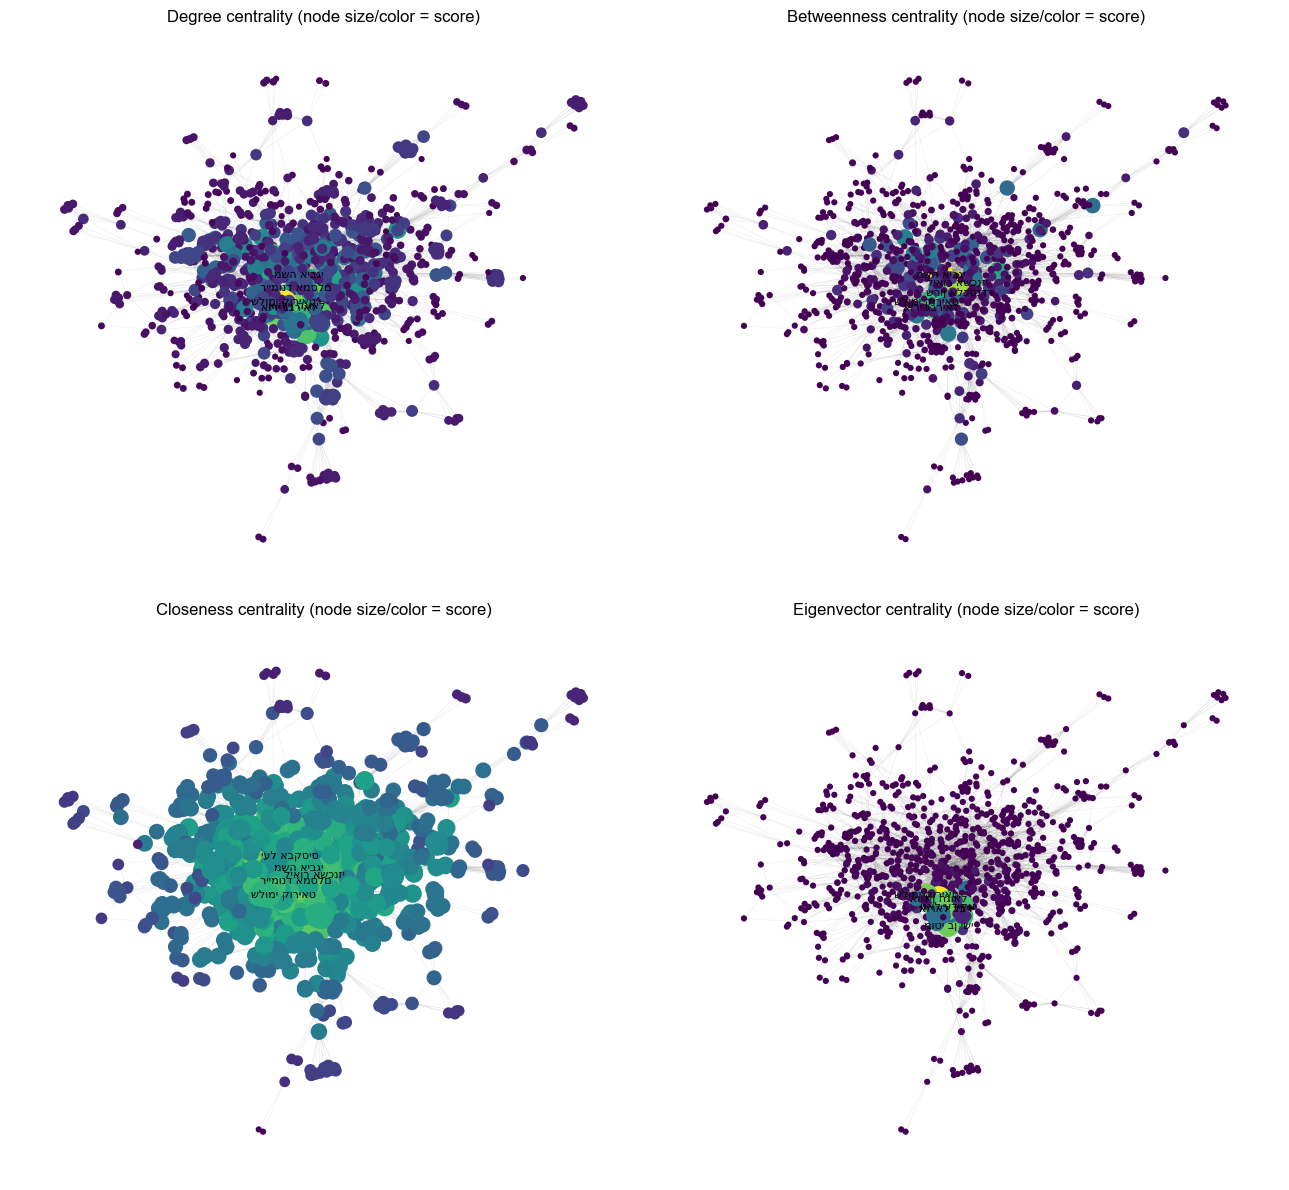

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
metrics_to_plot = ["degree", "betweenness", "closeness", "eigenvector"]
giant = utils.get_giant_component(H)
pos = nx.spring_layout(giant, seed=42, k=0.4 / np.sqrt(giant.number_of_nodes()))

for ax, metric in zip(axes.flat, metrics_to_plot):
    values = df.loc[list(giant.nodes), metric].fillna(0)
    sizes = 20 + 300 * (values - values.min()) / (values.max() - values.min() + 1e-9)
    nodes = nx.draw_networkx_nodes(giant, pos, ax=ax, node_size=sizes, node_color=values,
                                     cmap="viridis", linewidths=0)
    nx.draw_networkx_edges(giant, pos, ax=ax, alpha=0.08, width=0.4)
    top5 = values.sort_values(ascending=False).head(5).index
    nx.draw_networkx_labels(giant, pos, labels={n: H.nodes[n]["display_name"] for n in top5}, ax=ax, font_size=8)
    ax.set_title(f"{metric.capitalize()} centrality (node size/color = score)")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Full rankings (all actors, not just the top 15)

The tables above are 15-row previews for readability. Nothing is actually
limited to those 15 in the underlying data -- here is the **complete**
ranking for every actor, for each of the four centrality types
separately.

In [14]:
full_rankings = {
    "degree": df.sort_values("degree", ascending=False),
    "betweenness": df.sort_values("betweenness", ascending=False),
    "closeness": df.sort_values("closeness", ascending=False),
    "eigenvector": df.dropna(subset=["eigenvector"]).sort_values("eigenvector", ascending=False),
    "n_films": df.sort_values("n_films", ascending=False),
}
for metric, table in full_rankings.items():
    print(f"{metric}: {len(table)} actors ranked, from {table[metric].max():.4f} down to {table[metric].min():.4f}")

degree: 1106 actors ranked, from 0.0561 down to 0.0000
betweenness: 1106 actors ranked, from 0.0683 down to 0.0000
closeness: 1106 actors ranked, from 0.3437 down to 0.0000
eigenvector: 989 actors ranked, from 0.3019 down to 0.0000
n_films: 1106 actors ranked, from 23.0000 down to 1.0000


In [15]:
full_rankings["degree"]

,degree,betweenness,closeness,eigenvector,display_name,n_costars,n_collaborations,n_films,avg_distance_giant_component,most_important_costar
שלומי_קוריאט,0.056109,0.045582,0.330362,0.239087,שלומי קוריאט,62,81,8,2.706478,אוולין הגואל
משה_איבגי,0.051584,0.068262,0.343731,0.007123,משה איבגי,57,65,23,2.601215,אורי גבריאל
ריימונד_אמסלם,0.050679,0.042797,0.331478,0.030099,ריימונד אמסלם,56,67,13,2.697368,אוולין הגואל
אורי_גבריאל,0.049774,0.047807,0.327423,0.041967,אורי גבריאל,55,58,15,2.730769,יגאל עדיקא
אוולין_הגואל,0.045249,0.012991,0.315609,0.301898,אוולין הגואל,50,85,7,2.832996,יגאל עדיקא
...,...,...,...,...,...,...,...,...,...,...
צביקה_שוורצברג,0.000000,0.000000,0.000000,NaN,צביקה שוורצברג,0,0,1,NaN,None
רוזמונד_פייק,0.000000,0.000000,0.000000,NaN,רוזמונד פייק,0,0,1,NaN,None
זהבה_בן,0.000000,0.000000,0.000000,NaN,זהבה בן,0,0,1,NaN,None
__name__:תיעודי,0.000000,0.000000,0.000000,NaN,תיעודי,0,0,1,NaN,None


In [16]:
full_rankings["betweenness"]

,degree,betweenness,closeness,eigenvector,display_name,n_costars,n_collaborations,n_films,avg_distance_giant_component,most_important_costar
משה_איבגי,0.051584,0.068262,0.343731,0.007123,משה איבגי,57,65,23,2.601215,אורי גבריאל
ליאור_אשכנזי,0.044344,0.059129,0.341077,0.011672,ליאור אשכנזי,49,51,16,2.621457,עפר שכטר
שרון_אלכסנדר,0.043439,0.049824,0.316740,0.009812,שרון אלכסנדר,48,49,11,2.822874,יפה לוי
אורי_גבריאל,0.049774,0.047807,0.327423,0.041967,אורי גבריאל,55,58,15,2.730769,יגאל עדיקא
שלומי_קוריאט,0.056109,0.045582,0.330362,0.239087,שלומי קוריאט,62,81,8,2.706478,אוולין הגואל
...,...,...,...,...,...,...,...,...,...,...
__name__:אביתר מור,0.002715,0.000000,0.207319,0.000023,אביתר מור,3,3,1,4.312753,רועי ניק
אוגוסט_דיל,0.003620,0.000000,0.229213,0.000239,אוגוסט דיל,4,4,1,3.900810,עוז זהבי
__name__:סילביה הוקס,0.003620,0.000000,0.229213,0.000239,סילביה הוקס,4,4,1,3.900810,עוז זהבי
תמרה_קלינגון,0.003620,0.000000,0.180063,0.000167,תמרה קלינגון,4,4,1,4.965587,מעין וינשטוק


In [17]:
full_rankings["closeness"]

,degree,betweenness,closeness,eigenvector,display_name,n_costars,n_collaborations,n_films,avg_distance_giant_component,most_important_costar
משה_איבגי,0.051584,0.068262,0.343731,0.007123,משה איבגי,57,65,23,2.601215,אורי גבריאל
ליאור_אשכנזי,0.044344,0.059129,0.341077,0.011672,ליאור אשכנזי,49,51,16,2.621457,עפר שכטר
ריימונד_אמסלם,0.050679,0.042797,0.331478,0.030099,ריימונד אמסלם,56,67,13,2.697368,אוולין הגואל
שלומי_קוריאט,0.056109,0.045582,0.330362,0.239087,שלומי קוריאט,62,81,8,2.706478,אוולין הגואל
יעל_אבקסיס,0.034389,0.028987,0.328397,0.004650,יעל אבקסיס,38,44,14,2.722672,יגאל נאור
...,...,...,...,...,...,...,...,...,...,...
__name__:יהודה ברקן,0.000000,0.000000,0.000000,NaN,יהודה ברקן,0,0,1,NaN,None
רוזמונד_פייק,0.000000,0.000000,0.000000,NaN,רוזמונד פייק,0,0,1,NaN,None
__name__:ג'ניה צ'רניק,0.000000,0.000000,0.000000,NaN,ג'ניה צ'רניק,0,0,1,NaN,None
__name__:תיעודי,0.000000,0.000000,0.000000,NaN,תיעודי,0,0,1,NaN,None


In [18]:
full_rankings["eigenvector"]

,degree,betweenness,closeness,eigenvector,display_name,n_costars,n_collaborations,n_films,avg_distance_giant_component,most_important_costar
אוולין_הגואל,0.045249,0.012991,0.315609,3.018985e-01,אוולין הגואל,50,85,7,2.832996,יגאל עדיקא
יגאל_עדיקא,0.044344,0.008845,0.301087,2.397959e-01,יגאל עדיקא,49,69,6,2.969636,אוולין הגואל
שלומי_קוריאט,0.056109,0.045582,0.330362,2.390867e-01,שלומי קוריאט,62,81,8,2.706478,אוולין הגואל
מוטי_בן_ישי,0.040724,0.027038,0.293290,2.345303e-01,מוטי בן ישי,45,63,4,3.048583,אוולין הגואל
אוראל_צברי,0.037104,0.001661,0.289826,2.339557e-01,אוראל צברי,41,59,3,3.085020,אוולין הגואל
...,...,...,...,...,...,...,...,...,...,...
דני_שגב,0.001810,0.000000,0.142367,1.446716e-07,דני שגב,2,2,1,6.280364,אסיה נייפלד
__name__:רפי קלמר,0.001810,0.000000,0.142367,1.446716e-07,רפי קלמר,2,2,1,6.280364,אסיה נייפלד
רותי_אסרסאי,0.001810,0.000000,0.156435,1.330707e-07,רותי אסרסאי,2,2,1,5.715587,מאיר דסה
__name__:דבבה אשטו,0.001810,0.000000,0.156435,1.330707e-07,דבבה אשטו,2,2,1,5.715587,מאיר דסה


In [19]:
full_rankings["n_films"]

,degree,betweenness,closeness,eigenvector,display_name,n_costars,n_collaborations,n_films,avg_distance_giant_component,most_important_costar
משה_איבגי,0.051584,0.068262,0.343731,0.007123,משה איבגי,57,65,23,2.601215,אורי גבריאל
אלון_אבוטבול,0.036199,0.037799,0.326335,0.003801,אלון אבוטבול,40,44,21,2.739879,אורנה בנאי
ליאור_אשכנזי,0.044344,0.059129,0.341077,0.011672,ליאור אשכנזי,49,51,16,2.621457,עפר שכטר
אורי_גבריאל,0.049774,0.047807,0.327423,0.041967,אורי גבריאל,55,58,15,2.730769,יגאל עדיקא
יעל_אבקסיס,0.034389,0.028987,0.328397,0.004650,יעל אבקסיס,38,44,14,2.722672,יגאל נאור
...,...,...,...,...,...,...,...,...,...,...
__name__:אביתר מור,0.002715,0.000000,0.207319,0.000023,אביתר מור,3,3,1,4.312753,רועי ניק
אוגוסט_דיל,0.003620,0.000000,0.229213,0.000239,אוגוסט דיל,4,4,1,3.900810,עוז זהבי
__name__:סילביה הוקס,0.003620,0.000000,0.229213,0.000239,סילביה הוקס,4,4,1,3.900810,עוז זהבי
תמרה_קלינגון,0.003620,0.000000,0.180063,0.000167,תמרה קלינגון,4,4,1,4.965587,מעין וינשטוק


## Save centrality scores

In [20]:
try:
    df_bridge.to_csv("../data/processed/centrality_scores.csv", encoding="utf-8-sig")
    for metric, table in full_rankings.items():
        table.to_csv(f"../data/processed/centrality_full_{metric}.csv", encoding="utf-8-sig")
    center_df.to_csv("../data/processed/graph_center.csv", index=False, encoding="utf-8-sig")
    star_costars.to_csv("../data/processed/big_stars_costars.csv", index=False, encoding="utf-8-sig")
    print("Saved centrality_scores.csv, one centrality_full_<metric>.csv per type, "
          "graph_center.csv, and big_stars_costars.csv to data/processed/")
except PermissionError:
    print("Could not write centrality CSVs (likely locked by another program) -- skipping save.")

Saved centrality_scores.csv, one centrality_full_<metric>.csv per type, graph_center.csv, and big_stars_costars.csv to data/processed/


## Next steps

`06_link_prediction.ipynb`: train a link-prediction model on the 1990-2020
graph (using these centrality scores plus topological features and
embeddings), evaluate against actual 2020-2025 new collaborations, and
apply the best model to the full graph for exploratory future predictions.